In [1]:
import pandas as pd
import numpy as np
import os
import matplotlib.pyplot as plt
import seaborn as sns

# Prepare

In [2]:
def outcome(pred_base, pred_weighted, label, mode="2class"):
    """
    Compare baseline and weighted model predictions using a given evaluation mode.
    mode: one of {"regression", "7class", "5class", "2class", "2class_non0"}
    """

    if mode == "7class":
        base_correct = int(np.clip(pred_base, -3, 3)) == int(np.clip(label, -3, 3))
        weighted_correct = int(np.clip(pred_weighted, -3, 3)) == int(np.clip(label, -3, 3))

    elif mode == "5class":
        base_correct = int(np.clip(pred_base, -2, 2)) == int(np.clip(label, -2, 2))
        weighted_correct = int(np.clip(pred_weighted, -2, 2)) == int(np.clip(label, -2, 2))

    elif mode == "2class":
        base_correct = (pred_base >= 0) == (label >= 0)
        weighted_correct = (pred_weighted >= 0) == (label >= 0)

    elif mode == "2class_non0":
        if label == 0:
            return "ignore"
        base_correct = (pred_base > 0) == (label > 0)
        weighted_correct = (pred_weighted > 0) == (label > 0)

    else:
        raise ValueError("Unknown mode")

    if not base_correct and weighted_correct:
        return "corrected"
    elif base_correct and not weighted_correct:
        return "regressed"
    elif base_correct and weighted_correct:
        return "both_correct"
    else:
        return "both_wrong"


In [3]:
import ast

def to_float(x):
    if isinstance(x, float) or isinstance(x, int):
        return float(x)
    elif isinstance(x, list):
        return float(x[0])
    elif isinstance(x, str) and x.startswith("["):
        try:
            return float(ast.literal_eval(x)[0])
        except:
            return float('nan')
    else:
        return float(x)

In [4]:
def run_outcome_analysis(root_path, paths, dataset, model_base='baseline', model_weighted='KL'):
    # Load CSVs
    runs = {}
    for run_name, path in paths.items():
        df_train = pd.read_csv(f'{root_path}/{path}/{dataset}_text_audio_video_1_train_results.csv')
        df_dev   = pd.read_csv(f'{root_path}/{path}/{dataset}_text_audio_video_1_dev_results.csv')
        df_test  = pd.read_csv(f'{root_path}/{path}/{dataset}_text_audio_video_1_test_results.csv')

        #df_train["split"] = "train"
        #df_dev["split"]   = "dev"
        df_test["split"]  = "test"

        runs[run_name] = pd.concat([df_test], ignore_index=True)

    # Merge base and weighted runs
    merged = runs[model_base].merge(runs[model_weighted], on='ids', suffixes=(f'_{model_base}', f'_{model_weighted}'))

    # Keep a consistent GT and split column
    merged['Ground_Truth'] = merged[f'Ground_Truth_{model_base}']
    assert (merged[f'split_{model_base}'] == merged[f'split_{model_weighted}']).all()
    merged['split'] = merged[f'split_{model_base}']

    # Convert to float
    for col in [f'Predicted_{model_base}', f'Predicted_{model_weighted}', 'Ground_Truth']:
        merged[col] = merged[col].apply(to_float)

    # Classification-style outcome labeling
    modes = ["7class", "5class", "2class", "2class_non0"]
    for mode in modes:
        merged[f'outcome_{mode}'] = merged.apply(
            lambda r: outcome(r[f'Predicted_{model_base}'], r[f'Predicted_{model_weighted}'], r['Ground_Truth'], mode),
            axis=1
        )

    # Regression error analysis
    regression_df = merged[["ids", "split", f'Predicted_{model_base}', f'Predicted_{model_weighted}', "Ground_Truth"]].copy()
    regression_df["err_baseline"] = abs(regression_df[f'Predicted_{model_base}'] - regression_df["Ground_Truth"])
    regression_df["err_weighted"] = abs(regression_df[f'Predicted_{model_weighted}'] - regression_df["Ground_Truth"])
    regression_df["delta_err"] = regression_df["err_baseline"] - regression_df["err_weighted"]

    # Print summary for classification modes
    summary = {}
    for mode in modes:
        counts = merged[f'outcome_{mode}'].value_counts()
        summary[mode] = {
            'corrected': counts.get('corrected', 0),
            'regressed': counts.get('regressed', 0),
            'both_correct': counts.get('both_correct', 0),
            'both_wrong': counts.get('both_wrong', 0),
            'net_gain': counts.get('corrected', 0) - counts.get('regressed', 0)
        }

    print(pd.DataFrame(summary).T)
    print("\nRegression ΔError (baseline - weighted):")
    print(regression_df["delta_err"].describe())

    return merged, regression_df


# Local Residual KL

In [5]:
root_path = "/data/wang/junh/results/MMIM/"
paths = {
    "baseline":  "final/noWeights",
    "KL":        "final/kl_joint",
    "KL+CC":     "final/kl_joint_cc",
    "KL+MI":     "final/kl_joint_mi",
}

In [6]:
dataset = "mosi"
merged_mosi_kl, regression_mosi_kl = run_outcome_analysis(root_path, paths, dataset, model_base="baseline", model_weighted="KL")

             corrected  regressed  both_correct  both_wrong  net_gain
7class              91         80           267         248        11
5class              91         81           272         242        10
2class              44         32           523          87        12
2class_non0         35         31           520          70         4

Regression ΔError (baseline - weighted):
count    686.000000
mean       0.010746
std        0.537182
min       -2.909350
25%       -0.232673
50%       -0.001154
75%        0.264422
max        3.326085
Name: delta_err, dtype: float64


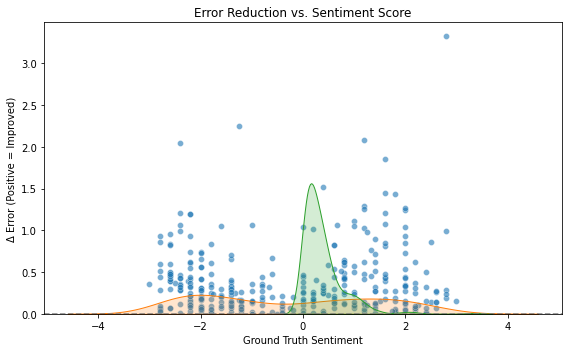

In [7]:
corrected_reg = regression_mosi_kl[regression_mosi_kl["delta_err"] > 0].copy()
plt.figure(figsize=(8, 5))
sns.scatterplot(x="Ground_Truth", y="delta_err", data=corrected_reg, alpha=0.6)
sns.kdeplot(x="Ground_Truth", data=corrected_reg, fill=True, alpha=0.2)
sns.kdeplot(x="delta_err", data=corrected_reg, fill=True, alpha=0.2)


plt.axhline(0, color='gray', linestyle='--')
plt.title("Error Reduction vs. Sentiment Score")
plt.xlabel("Ground Truth Sentiment")
plt.ylabel("Δ Error (Positive = Improved)")
plt.tight_layout()
plt.show()

In [8]:
dataset = "mosei"
merged_mosei_kl, regression_mosei_kl = run_outcome_analysis(root_path, paths, dataset, model_base="baseline", model_weighted="KL")

             corrected  regressed  both_correct  both_wrong  net_gain
7class             476        456          2467        1260        20
5class             498        456          2467        1238        42
2class             580        256          3267         556       324
2class_non0        308        236          2754         336        72

Regression ΔError (baseline - weighted):
count    4659.000000
mean        0.000887
std         0.433751
min        -3.392145
25%        -0.179268
50%         0.008857
75%         0.210505
max         3.272220
Name: delta_err, dtype: float64


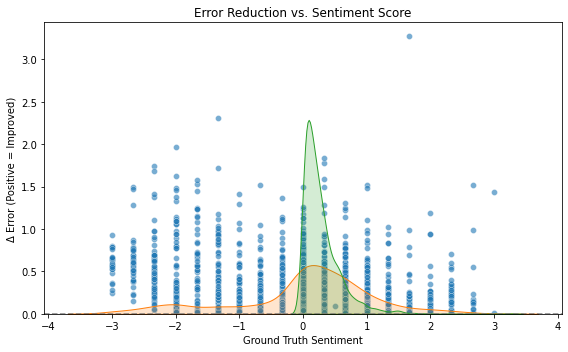

In [9]:
corrected_reg = regression_mosei_kl[regression_mosei_kl["delta_err"] > 0].copy()
plt.figure(figsize=(8, 5))
sns.scatterplot(x="Ground_Truth", y="delta_err", data=corrected_reg, alpha=0.6)
sns.kdeplot(x="Ground_Truth", data=corrected_reg, fill=True, alpha=0.2)
sns.kdeplot(x="delta_err", data=corrected_reg, fill=True, alpha=0.2)


plt.axhline(0, color='gray', linestyle='--')
plt.title("Error Reduction vs. Sentiment Score")
plt.xlabel("Ground Truth Sentiment")
plt.ylabel("Δ Error (Positive = Improved)")
plt.tight_layout()
plt.show()

In [10]:
dataset = "mosi"
merged_mosi_kl_cc, regression_mosi_kl_cc = run_outcome_analysis(root_path, paths, dataset, model_base="baseline", model_weighted="KL+CC")

             corrected  regressed  both_correct  both_wrong  net_gain
7class              75         77           270         264        -2
5class              75         79           274         258        -4
2class              34         26           529          97         8
2class_non0         28         25           526          77         3

Regression ΔError (baseline - weighted):
count    686.000000
mean       0.001341
std        0.481274
min       -2.561930
25%       -0.209892
50%       -0.004107
75%        0.211723
max        2.130282
Name: delta_err, dtype: float64


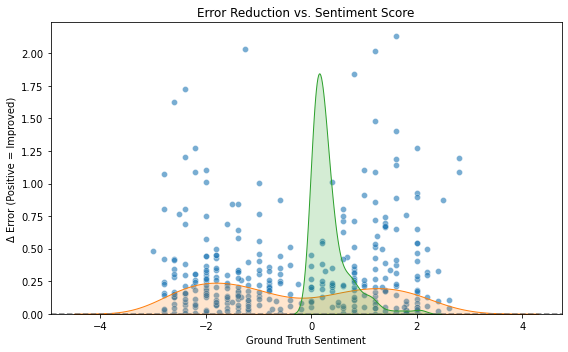

In [11]:
corrected_reg = regression_mosi_kl_cc[regression_mosi_kl_cc["delta_err"] > 0].copy()
plt.figure(figsize=(8, 5))
sns.scatterplot(x="Ground_Truth", y="delta_err", data=corrected_reg, alpha=0.6)
sns.kdeplot(x="Ground_Truth", data=corrected_reg, fill=True, alpha=0.2)
sns.kdeplot(x="delta_err", data=corrected_reg, fill=True, alpha=0.2)


plt.axhline(0, color='gray', linestyle='--')
plt.title("Error Reduction vs. Sentiment Score")
plt.xlabel("Ground Truth Sentiment")
plt.ylabel("Δ Error (Positive = Improved)")
plt.tight_layout()
plt.show()

In [12]:
dataset = "mosei"
merged_mosei_kl_cc, regression_mosei_kl_cc  = run_outcome_analysis(root_path, paths, dataset, model_base="baseline", model_weighted="KL+CC")

             corrected  regressed  both_correct  both_wrong  net_gain
7class             567        401          2522        1169       166
5class             589        401          2522        1147       188
2class             431        357          3166         705        74
2class_non0        286        280          2710         358         6

Regression ΔError (baseline - weighted):
count    4659.000000
mean        0.048333
std         0.469803
min        -3.113464
25%        -0.171016
50%         0.028804
75%         0.269649
max         2.620457
Name: delta_err, dtype: float64


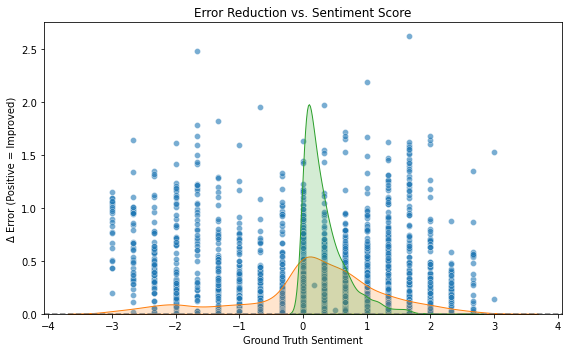

In [13]:
corrected_reg = regression_mosei_kl_cc[regression_mosei_kl_cc["delta_err"] > 0].copy()
plt.figure(figsize=(8, 5))
sns.scatterplot(x="Ground_Truth", y="delta_err", data=corrected_reg, alpha=0.6)
sns.kdeplot(x="Ground_Truth", data=corrected_reg, fill=True, alpha=0.2)
sns.kdeplot(x="delta_err", data=corrected_reg, fill=True, alpha=0.2)


plt.axhline(0, color='gray', linestyle='--')
plt.title("Error Reduction vs. Sentiment Score")
plt.xlabel("Ground Truth Sentiment")
plt.ylabel("Δ Error (Positive = Improved)")
plt.tight_layout()
plt.show()

In [14]:
dataset = "mosi"
merged_mosi_kl_mi, regression_mosi_kl_mi  = run_outcome_analysis(root_path, paths, dataset, model_base="baseline", model_weighted="KL+MI")

             corrected  regressed  both_correct  both_wrong  net_gain
7class              57         72           275         282       -15
5class              57         73           280         276       -16
2class              34         24           531          97        10
2class_non0         28         23           528          77         5

Regression ΔError (baseline - weighted):
count    686.000000
mean      -0.001597
std        0.493127
min       -2.708061
25%       -0.190040
50%        0.004723
75%        0.196018
max        3.165357
Name: delta_err, dtype: float64


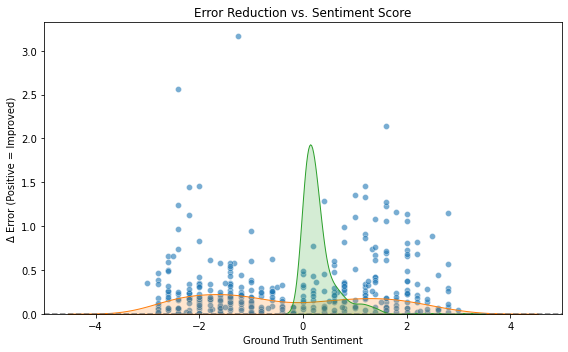

In [15]:
corrected_reg = regression_mosi_kl_mi[regression_mosi_kl_mi["delta_err"] > 0].copy()
plt.figure(figsize=(8, 5))
sns.scatterplot(x="Ground_Truth", y="delta_err", data=corrected_reg, alpha=0.6)
sns.kdeplot(x="Ground_Truth", data=corrected_reg, fill=True, alpha=0.2)
sns.kdeplot(x="delta_err", data=corrected_reg, fill=True, alpha=0.2)


plt.axhline(0, color='gray', linestyle='--')
plt.title("Error Reduction vs. Sentiment Score")
plt.xlabel("Ground Truth Sentiment")
plt.ylabel("Δ Error (Positive = Improved)")
plt.tight_layout()
plt.show()

In [16]:
dataset = "mosei"
merged_mosei_kl_mi, regression_mosei_kl_mi  = run_outcome_analysis(root_path, paths, dataset, model_base="baseline", model_weighted="KL+MI")

             corrected  regressed  both_correct  both_wrong  net_gain
7class             445        380          2543        1291        65
5class             465        380          2543        1271        85
2class             444        333          3190         692       111
2class_non0        284        268          2722         360        16

Regression ΔError (baseline - weighted):
count    4659.000000
mean        0.019669
std         0.402550
min        -2.223937
25%        -0.156807
50%         0.016737
75%         0.214786
max         2.595043
Name: delta_err, dtype: float64


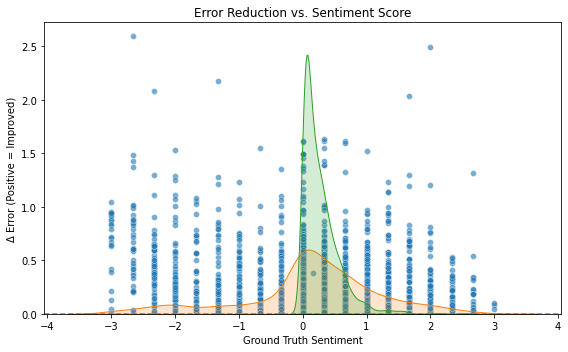

In [17]:
corrected_reg = regression_mosei_kl_mi[regression_mosei_kl_mi["delta_err"] > 0].copy()
plt.figure(figsize=(8, 5))
sns.scatterplot(x="Ground_Truth", y="delta_err", data=corrected_reg, alpha=0.6)
sns.kdeplot(x="Ground_Truth", data=corrected_reg, fill=True, alpha=0.2)
sns.kdeplot(x="delta_err", data=corrected_reg, fill=True, alpha=0.2)


plt.axhline(0, color='gray', linestyle='--')
plt.title("Error Reduction vs. Sentiment Score")
plt.xlabel("Ground Truth Sentiment")
plt.ylabel("Δ Error (Positive = Improved)")
plt.tight_layout()
plt.show()